<a href="https://colab.research.google.com/github/euleralencar/projeto_ciencia_dados_ibmec/blob/main/02_3_numerical_pipeline_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pré-processamento para features numéricas

Neste notebook, continuamos usando apenas features numéricas.

Aqui introduzimos estes novos aspectos:

* um exemplo de pré-processamento, especificamente **escalonamento de variáveis
  numéricas**;
* uso de um **pipeline** do scikit-learn para encadear pré-processamento e
  treinamento do modelo.

## Preparação dos dados

Primeiro, vamos carregar o conjunto de dados completo do censo norte-americano.

In [1]:
import pandas as pd

adult_census = pd.read_csv(
    "https://raw.githubusercontent.com/INRIA/scikit-learn-mooc/main/datasets/adult-census.csv"
)

Agora removemos o alvo dos dados que usamos para treinar nosso modelo
preditivo.

In [2]:
target_name = "class"
target = adult_census[target_name]
data = adult_census.drop(columns=target_name)

Em seguida, selecionamos apenas as colunas numéricas, como visto no notebook
anterior.

In [3]:
numerical_columns = ["age", "capital-gain", "capital-loss", "hours-per-week"]

data_numeric = data[numerical_columns]

Por fim, podemos dividir nosso conjunto de dados em conjuntos de treino e
teste.

In [4]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data_numeric, target, random_state=42
)

## Ajuste do modelo com pré-processamento

Uma série de algoritmos de pré-processamento no scikit-learn nos permite
transformar os dados de entrada antes de treinar um modelo. No nosso caso,
vamos padronizar os dados e depois treinar um novo modelo de regressão
logística nessa nova versão do conjunto de dados.

Vamos começar imprimindo algumas estatísticas sobre os dados de treino.

In [5]:
data_train.describe()

,age,capital-gain,capital-loss,hours-per-week
count,36631.000000,36631.000000,36631.000000,36631.000000
mean,38.642352,1087.077721,89.665311,40.431247
std,13.725748,7522.692939,407.110175,12.423952
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


Vemos que as features do conjunto de dados abrangem faixas diferentes. Alguns
algoritmos fazem certas suposições sobre as distribuições das features, e
normalizar as features geralmente ajuda a atender a essas suposições.

<div class="admonition tip alert alert-warning">
<p class="first admonition-title" style="font-weight: bold;">Dica</p>
<p>Aqui estão alguns motivos para escalonar as features:</p>
<ul class="last simple">
<li>Modelos que dependem da distância entre um par de amostras, como o k-nearest
neighbors, devem ser treinados com features normalizadas para que cada feature
contribua de forma aproximadamente igual nos cálculos de distância.</li>
<li>Muitos modelos, como a regressão logística, usam um solver numérico (baseado em
gradiente descendente) para encontrar seus parâmetros ótimos. Esse solver
converge mais rápido quando as features são escalonadas, pois requer menos
passos (chamados de <strong>iterações</strong>) para atingir a solução ótima.</li>
</ul>
</div>

Se um modelo de aprendizado de máquina requer ou não o escalonamento das
features depende da família do modelo. Modelos lineares, como a regressão
logística, geralmente se beneficiam do escalonamento das features, enquanto
outros modelos, como árvores de decisão, não precisam desse pré-processamento
(mas também não seriam prejudicados por ele).

Mostramos como aplicar essa normalização usando um transformador do
scikit-learn chamado `StandardScaler`. Esse transformador desloca e escalona
cada feature individualmente, de modo que todas tenham média 0 e desvio padrão
unitário. Lembramos que transformadores são estimadores que possuem um método
`transform`.

Agora investigamos os diferentes passos usados no scikit-learn para realizar
essa transformação dos dados.

Primeiro, é preciso chamar o método `fit` para aprender o escalonamento a
partir dos dados.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(data_train)

StandardScaler()

O método `fit` para transformadores é semelhante ao método `fit` para
preditores. A principal diferença é que o primeiro tem um único argumento (a
matriz de dados), enquanto o segundo tem dois argumentos (a matriz de dados e o
alvo).

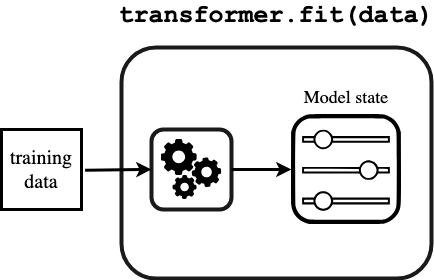



Neste caso, o algoritmo precisa calcular a média e o desvio padrão de cada feature e armazená-los em arrays do NumPy. Aqui, essas estatísticas são os estados do modelo.

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p class="last">O fato de os estados do modelo deste escalonador serem arrays
de médias e desvios padrão é específico do <tt class="docutils
literal">StandardScaler</tt>. Outros transformadores do scikit-learn podem calcular estatísticas diferentes e armazená-las como estados do modelo, de forma semelhante.</p>
</div>

Podemos inspecionar as médias e os desvios padrão calculados.

In [7]:
scaler.mean_

array([  38.64235211, 1087.07772106,   89.6653108 ,   40.43124676])

In [8]:
scaler.scale_

array([  13.72556083, 7522.59025606,  407.10461772,   12.42378265])

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p class="last">Convenção do scikit-learn: se um atributo é aprendido a partir
dos dados, seu nome termina com um sublinhado (ou seja, <tt class="docutils
literal">_</tt>), como em <tt class="docutils literal">mean_</tt> e <tt
class="docutils literal">scale_</tt> para o <tt class="docutils
literal">StandardScaler</tt>.</p>
</div>

O escalonamento dos dados é aplicado a cada feature individualmente (ou seja,
cada coluna da matriz de dados). Para cada feature, subtraímos sua média e
dividimos pelo seu desvio padrão.

Depois de chamar o método `fit`, podemos realizar a transformação dos dados
chamando o método `transform`.

In [9]:
data_train_scaled = scaler.transform(data_train)
data_train_scaled

array([[ 0.17177061, -0.14450843,  5.71188483, -2.28845333],
       [ 0.02605707, -0.14450843, -0.22025127, -0.27618374],
       [-0.33822677, -0.14450843, -0.22025127,  0.77019645],
       ...,
       [-0.77536738, -0.14450843, -0.22025127, -0.03471139],
       [ 0.53605445, -0.14450843, -0.22025127, -0.03471139],
       [ 1.48319243, -0.14450843, -0.22025127, -2.69090725]])

Vamos ilustrar o mecanismo interno do método `transform` e colocá-lo em
perspectiva com o que já vimos com os preditores.

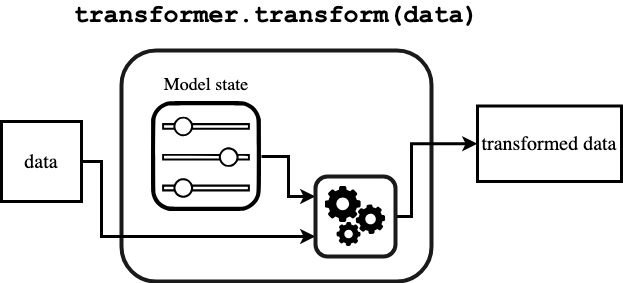

O método `transform` dos transformadores é semelhante ao método `predict` dos preditores. Ele usa uma função predefinida, chamada de **função de transformação**, e utiliza os estados do modelo e os dados de entrada. No entanto, em vez de gerar previsões, a função do método `transform` é gerar uma versão transformada dos dados de entrada.

Por fim, o método `fit_transform` é um atalho para chamar sucessivamente `fit` e depois `transform`.

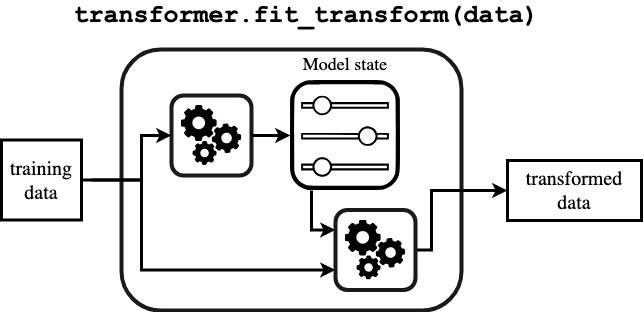

No jargão do scikit-learn, um **transformador** é definido como um estimador
(um objeto com um método `fit`) que suporta `transform` ou `fit_transform`.

In [10]:
data_train_scaled = scaler.fit_transform(data_train)
data_train_scaled

array([[ 0.17177061, -0.14450843,  5.71188483, -2.28845333],
       [ 0.02605707, -0.14450843, -0.22025127, -0.27618374],
       [-0.33822677, -0.14450843, -0.22025127,  0.77019645],
       ...,
       [-0.77536738, -0.14450843, -0.22025127, -0.03471139],
       [ 0.53605445, -0.14450843, -0.22025127, -0.03471139],
       [ 1.48319243, -0.14450843, -0.22025127, -2.69090725]])

Por padrão, todos os transformadores do scikit-learn geram arrays do NumPy.
Desde a versão 1.2 do scikit-learn, é possível configurar a saída para ser um
dataframe do pandas, o que facilita a exploração dos dados, pois preserva os
nomes das colunas. O método `set_output` controla esse comportamento. Consulte
este [exemplo da documentação do
scikit-learn](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_set_output.html)
para mais opções de configuração da saída dos transformadores.

In [11]:
scaler = StandardScaler().set_output(transform="pandas")
data_train_scaled = scaler.fit_transform(data_train)
data_train_scaled.describe()

,age,capital-gain,capital-loss,hours-per-week
count,3.663100e+04,3.663100e+04,3.663100e+04,3.663100e+04
mean,-2.273364e-16,3.530310e-17,3.840667e-17,1.844684e-16
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.576792e+00,-1.445084e-01,-2.202513e-01,-3.173852e+00
25%,-7.753674e-01,-1.445084e-01,-2.202513e-01,-3.471139e-02
50%,-1.196565e-01,-1.445084e-01,-2.202513e-01,-3.471139e-02
75%,6.817680e-01,-1.445084e-01,-2.202513e-01,3.677425e-01
max,3.741752e+00,1.314865e+01,1.047970e+01,4.714245e+00


Note que a média de todas as colunas está próxima de 0 e o desvio padrão, em
todos os casos, está próximo de 1. Também podemos visualizar o efeito do
`StandardScaler` usando um jointplot, que mostra tanto os histogramas das
distribuições quanto um gráfico de dispersão de qualquer par de features
numéricas ao mesmo tempo. Podemos observar que o `StandardScaler` não altera a
estrutura dos dados em si, mas os eixos são deslocados e escalonados.

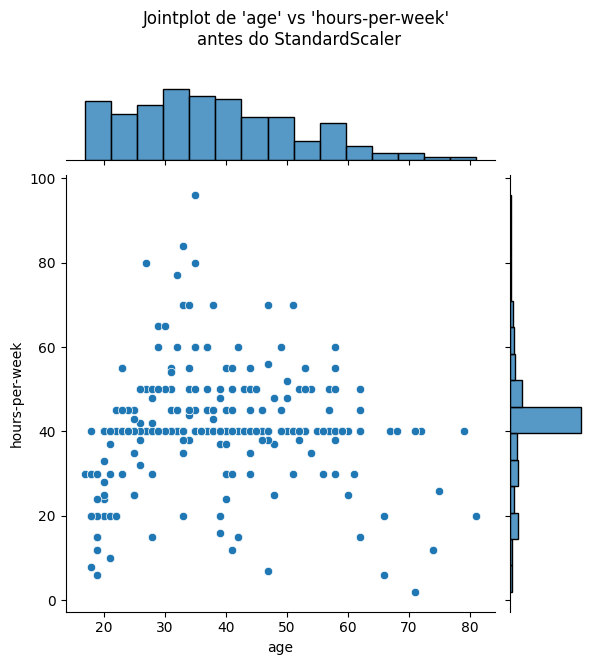

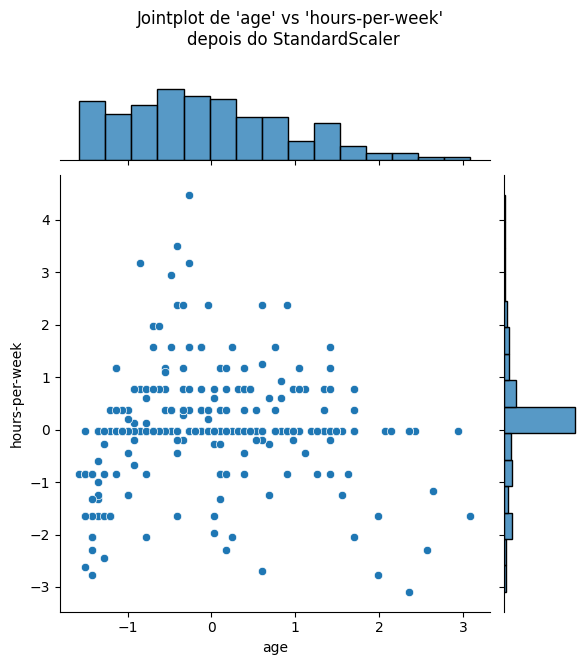

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# número de pontos a visualizar para ter um gráfico mais claro
num_points_to_plot = 300

sns.jointplot(
    data=data_train[:num_points_to_plot],
    x="age",
    y="hours-per-week",
    marginal_kws=dict(bins=15),
)
plt.suptitle(
    "Jointplot de 'age' vs 'hours-per-week' \nantes do StandardScaler", y=1.1
)

sns.jointplot(
    data=data_train_scaled[:num_points_to_plot],
    x="age",
    y="hours-per-week",
    marginal_kws=dict(bins=15),
)
_ = plt.suptitle(
    "Jointplot de 'age' vs 'hours-per-week' \ndepois do StandardScaler", y=1.1
)

Podemos combinar facilmente operações sequenciais com um `Pipeline` do
scikit-learn, que encadeia as operações e é usado como qualquer outro
classificador ou regressor. A função utilitária `make_pipeline` cria um
`Pipeline`: ela recebe como argumentos as transformações sucessivas a serem
realizadas, seguidas do modelo classificador ou regressor.

In [13]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression())
model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

A função `make_pipeline` não exigiu que déssemos um nome a cada etapa. Na
verdade, o nome foi atribuído automaticamente com base no nome das classes
fornecidas; uma etapa `StandardScaler` é chamada de `"standardscaler"` no
pipeline resultante. Podemos verificar o nome de cada etapa do nosso modelo:

In [14]:
model.named_steps

{'standardscaler': StandardScaler(),
 'logisticregression': LogisticRegression()}

Esse pipeline preditivo expõe os mesmos métodos que o preditor final: `fit` e
`predict` (e, adicionalmente, `predict_proba`, `decision_function` ou `score`).

In [15]:
start = time.time()
model.fit(data_train, target_train)
elapsed_time = time.time() - start

Podemos representar o mecanismo interno de um pipeline ao chamar `fit` pelo seguinte diagrama:

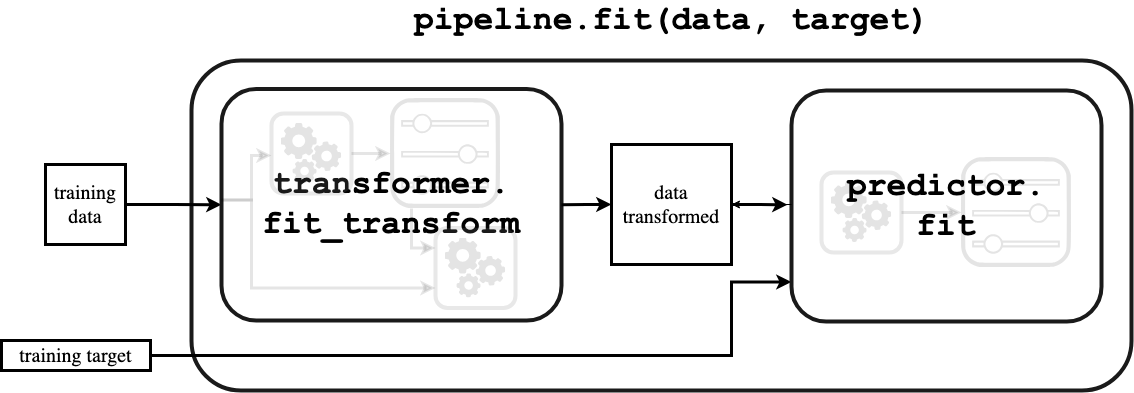

Ao chamar `model.fit`, o método `fit_transform` de cada transformador
subjacente (aqui, um único transformador) no pipeline é chamado para:

- aprender seus estados internos do modelo
- transformar os dados de treino. Por fim, os dados pré-processados são
  fornecidos para treinar o preditor.

Para prever os alvos dado um conjunto de teste, usa-se o método `predict`.

In [16]:
predicted_target = model.predict(data_test)
predicted_target[:5]

array([' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K'], dtype=object)

Vamos mostrar o mecanismo subjacente:


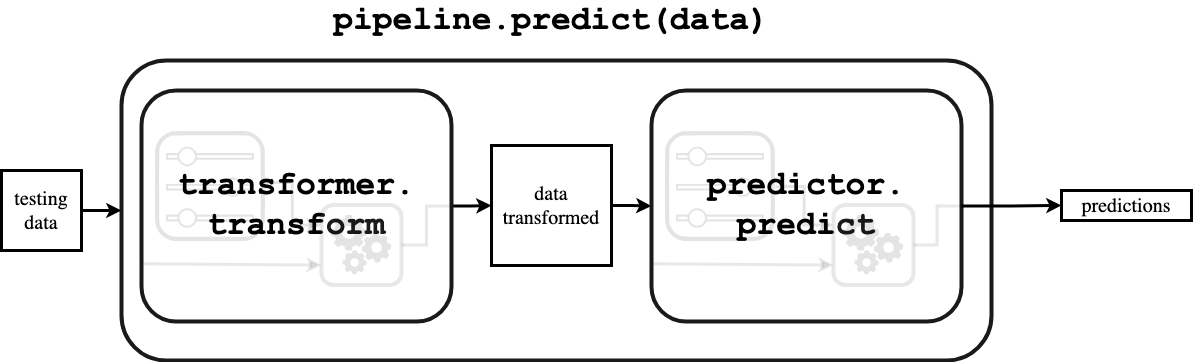

O método `transform` de cada transformador (aqui, um único transformador) é
chamado para pré-processar os dados. Note que não é necessário chamar o método
`fit` para esses transformadores, pois estamos usando os estados internos do
modelo calculados ao chamar `model.fit`. Os dados pré-processados são então
fornecidos ao preditor, que gera o alvo previsto chamando seu método `predict`.

Como atalho, podemos verificar o score do pipeline preditivo completo chamando
o método `model.score`. Assim, vamos verificar o desempenho computacional e de
generalização desse pipeline preditivo.

In [17]:
model_name = model.__class__.__name__
score = model.score(data_test, target_test)
print(
    f"A acurácia usando um {model_name} é {score:.3f} "
    f"com um tempo de ajuste de {elapsed_time:.3f} segundos "
    f"em {model[-1].n_iter_[0]} iterações"
)

A acurácia usando um Pipeline é 0.807 com um tempo de ajuste de 0.099 segundos em 9 iterações


Poderíamos comparar esse modelo preditivo com o modelo preditivo usado no
notebook anterior, que não escalonava as features.

In [18]:
model = LogisticRegression()
start = time.time()
model.fit(data_train, target_train)
elapsed_time = time.time() - start

In [19]:
model_name = model.__class__.__name__
score = model.score(data_test, target_test)
print(
    f"A acurácia usando um {model_name} é {score:.3f} "
    f"com um tempo de ajuste de {elapsed_time:.3f} segundos "
    f"em {model.n_iter_[0]} iterações"
)

A acurácia usando um LogisticRegression é 0.807 com um tempo de ajuste de 0.454 segundos em 60 iterações


Vemos que escalonar os dados antes de treinar a regressão logística foi
benéfico em termos de desempenho computacional. De fato, o número de iterações
diminuiu, assim como o tempo de treinamento. O desempenho de generalização não
mudou, já que ambos os modelos convergiram.

<div class="admonition warning alert alert-danger">
<p class="first admonition-title" style="font-weight: bold;">Atenção</p>
<p class="last">Trabalhar com dados não escalonados pode potencialmente forçar
o algoritmo a iterar mais, como mostramos no exemplo acima. Há também o cenário
catastrófico em que o número de iterações necessárias é maior do que o número
máximo de iterações permitido pelo preditor (controlado pelo parâmetro <tt
class="docutils literal">max_iter</tt>). Portanto, antes de aumentar o <tt
class="docutils literal">max_iter</tt>, certifique-se de que os dados estejam
bem escalonados.</p>
</div>

Neste notebook, nós:

* vimos a importância do **escalonamento de variáveis numéricas**;
* usamos um **pipeline** para encadear o escalonamento e o treinamento da
  regressão logística.